In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, AveragePooling2D, BatchNormalization, Activation, Concatenate, GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

dataset_path = '/content/drive/MyDrive/dataset_for_lab5'
IMG_SIZE = (150, 150)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = train_datagen.flow_from_directory(
    dataset_path, target_size=IMG_SIZE, batch_size=32,
    class_mode='binary', subset='training', seed=42
)

val_generator = val_datagen.flow_from_directory(
    dataset_path, target_size=IMG_SIZE, batch_size=32,
    class_mode='binary', subset='validation', shuffle=False, seed=42
)

def conv2d_bn(x, filters, num_row, num_col, padding='same', strides=(1, 1)):
    x = Conv2D(filters, (num_row, num_col), strides=strides, padding=padding, use_bias=False)(x)
    x = BatchNormalization(scale=False)(x)
    x = Activation('relu')(x)
    return x

def inception_module_A(x):
    branch1x1 = conv2d_bn(x, 16, 1, 1)

    branch5x5 = conv2d_bn(x, 16, 1, 1)
    branch5x5 = conv2d_bn(branch5x5, 24, 3, 3)
    branch5x5 = conv2d_bn(branch5x5, 24, 3, 3)

    branch3x3dbl = conv2d_bn(x, 16, 1, 1)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 24, 3, 3)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 24, 3, 3)

    branch_pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = conv2d_bn(branch_pool, 16, 1, 1)

    return Concatenate(axis=3)([branch1x1, branch5x5, branch3x3dbl, branch_pool])

def inception_module_B(x):
    branch1x1 = conv2d_bn(x, 24, 1, 1)

    branch7x7 = conv2d_bn(x, 24, 1, 1)
    branch7x7 = conv2d_bn(branch7x7, 24, 1, 7)
    branch7x7 = conv2d_bn(branch7x7, 24, 7, 1)

    branch7x7dbl = conv2d_bn(x, 24, 1, 1)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 24, 7, 1)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 24, 1, 7)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 24, 7, 1)
    branch7x7dbl = conv2d_bn(branch7x7dbl, 24, 1, 7)

    branch_pool = AveragePooling2D((3, 3), strides=(1, 1), padding='same')(x)
    branch_pool = conv2d_bn(branch_pool, 24, 1, 1)

    return Concatenate(axis=3)([branch1x1, branch7x7, branch7x7dbl, branch_pool])

def reduction_block(x):
    branch3x3 = conv2d_bn(x, 32, 3, 3, strides=(2, 2), padding='valid')

    branch3x3dbl = conv2d_bn(x, 16, 1, 1)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 24, 3, 3)
    branch3x3dbl = conv2d_bn(branch3x3dbl, 24, 3, 3, strides=(2, 2), padding='valid')

    branch_pool = MaxPooling2D((3, 3), strides=(2, 2))(x)
    return Concatenate(axis=3)([branch3x3, branch3x3dbl, branch_pool])

def build_inception_v3(input_shape=(150, 150, 3)):
    img_input = Input(shape=input_shape)

    x = conv2d_bn(img_input, 16, 3, 3, strides=(2, 2), padding='valid')
    x = conv2d_bn(x, 16, 3, 3, padding='valid')
    x = conv2d_bn(x, 32, 3, 3)
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = conv2d_bn(x, 32, 1, 1, padding='valid')
    x = conv2d_bn(x, 64, 3, 3, padding='valid')
    x = MaxPooling2D((3, 3), strides=(2, 2))(x)

    x = inception_module_A(x)
    x = reduction_block(x)
    x = inception_module_B(x)

    x = GlobalAveragePooling2D(name='avg_pool')(x)
    x = Dropout(0.4)(x)
    predictions = Dense(1, activation='sigmoid', name='predictions')(x)

    return Model(inputs=img_input, outputs=predictions, name='inception')

model = build_inception_v3()

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1)

class_weights = compute_class_weight('balanced', classes=np.unique(train_generator.classes), y=train_generator.classes)
class_weight_dict = dict(enumerate(class_weights))

history = model.fit(
    train_generator,
    epochs=40,
    validation_data=val_generator,
    callbacks=[early_stop],
    class_weight=class_weight_dict
)

model.save('shi_tzu_classifier.keras')

val_generator.reset()
y_pred_probs = model.predict(val_generator)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()
y_true = val_generator.classes

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
conf_matrix = confusion_matrix(y_true, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=val_generator.class_indices.keys(),
            yticklabels=val_generator.class_indices.keys())
plt.title('Confusion Matrix')
plt.ylabel('Справжній клас')
plt.xlabel('Передбачений клас')
plt.show()

Знайдено 6 зображень
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


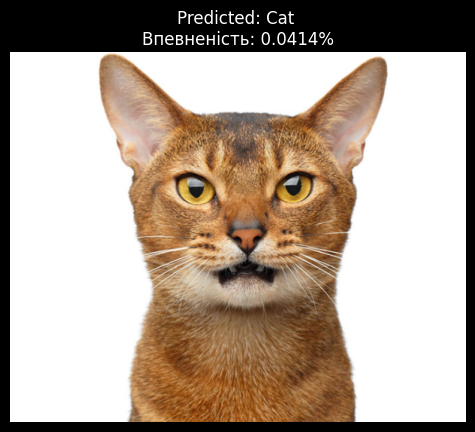

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


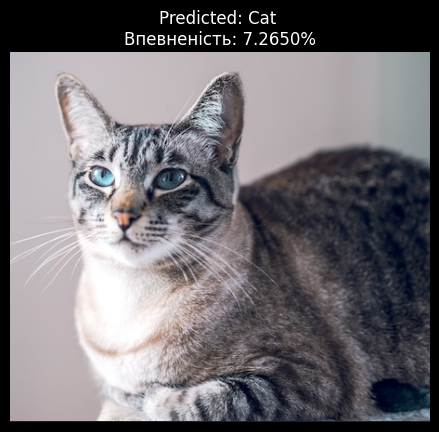

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


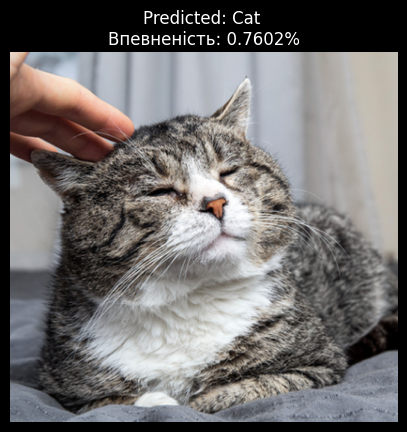

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


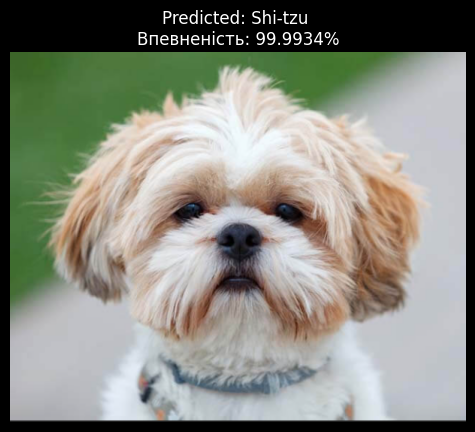

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


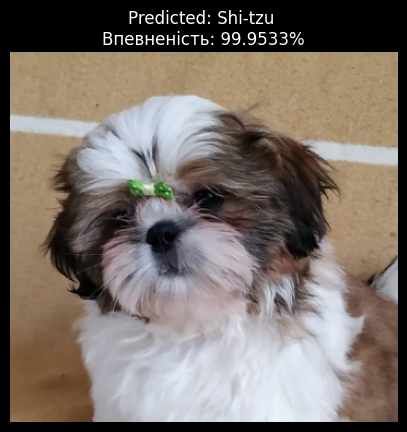

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


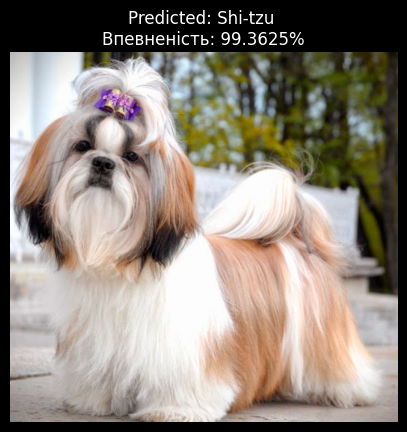

In [12]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import numpy as np, glob, os, matplotlib.pyplot as plt

model = load_model('shi_tzu_classifier.keras')
class_indices = {'Cat': 0, 'Shi-tzu': 1}
def predict_animal(model, img_path, class_indices):
    img = image.load_img(img_path, target_size=(150, 150))
    img_original = image.load_img(img_path)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    classes = {v: k for k, v in class_indices.items()}
    predicted_class_idx = 1 if prediction > 0.5 else 0
    class_label = classes[predicted_class_idx]

    plt.imshow(img_original)
    plt.title(f"Predicted: {class_label}\nВпевненість: {prediction*100:.4f}%")
    plt.axis('off')
    plt.show()

base_path = "lab5_imgs/"
imgs = glob.glob(os.path.join(base_path, "**", "*.png"), recursive=True)
imgs += glob.glob(os.path.join(base_path, "**", "*.jpg"), recursive=True)
if not imgs:
    print(f"No images were found in {base_path}")
else:
    print(f"Знайдено {len(imgs)} зображень")
    for img in imgs:
        predict_animal(model, img, class_indices)